In [1]:
#using google colab so use this to import dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#store dataset path and print if loaded sucessfully
dataset_path = '/content/drive/MyDrive/DHC/task2/WA_Fn-UseC_-Telco-Customer-Churn.csv'
print(f"data set path loaded sucessfully {dataset_path}")

data set path loaded sucessfully /content/drive/MyDrive/DHC/task2/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
import pandas as pd

In [41]:
#import all required libraries
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
#read dataset and store it in df
df = pd.read_csv(dataset_path)

In [5]:
#print top 10 samples of data set
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [11]:
df.shape

(7043, 21)

In [12]:
print(f'Columns: {list(df.columns)}')

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [14]:
#checking null values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [19]:
# STEP 4: DATA CLEANING

# The customerID column is removed because it is only an identifier.

df = df.drop("customerID", axis=1)


# The TotalCharges column should be numerical.
# errors="coerce" converts invalid blank values into NaN.

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [20]:
# Check missing values after converting TotalCharges
print("Missing Values After Conversion:")
print(df.isnull().sum())

Missing Values After Conversion:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [21]:
# Convert the target variable into binary format.
# Yes means the customer churned, so it is encoded as 1.
# No means the customer did not churn, so it is encoded as 0.

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [23]:
# SEPARATE FEATURES AND TARGET VARIABLE
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [24]:
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [26]:
#Replacing missing numerical values with the median.
#Scaling numerical features using StandardScaler.

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [28]:
# Replacing missing categorical values with the most frequent value.
# Converting categorical values into numerical format using One-Hot Encoding.

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

In [29]:
# ColumnTransformer applies different preprocessing steps
# to numerical and categorical columns separately.

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

In [30]:
#SPLIT DATA INTO TRAINING AND TESTING SETS

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [32]:
# HYPERPARAMETERS FOR LOGISTIC REGRESSION
# GridSearchCV will test different values of C and solver.
# C controls regularization strength.
# solver defines the optimization algorithm.

logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

In [33]:
# TRAIN LOGISTIC REGRESSION USING GRIDSEARCHCV
# GridSearchCV performs cross-validation and selects the best hyperparameter combination.

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(logistic_grid.best_params_)

print("\nBest Logistic Regression CV Accuracy:")
print(logistic_grid.best_score_)

Best Logistic Regression Parameters:
{'model__C': 0.01, 'model__solver': 'liblinear'}

Best Logistic Regression CV Accuracy:
0.8047557056647665


In [34]:
# CREATE RANDOM FOREST PIPELINE
# This pipeline first applies preprocessing and then trains a Random Forest classifier.

random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [35]:
# DEFINE HYPERPARAMETERS FOR RANDOM FOREST

# n_estimators defines the number of trees in the forest.
# max_depth controls the maximum depth of each tree.
# min_samples_split controls the minimum samples required to split a node.

random_forest_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

In [36]:
# TRAINing RANDOM FOREST USING GRIDSEARCHCV
random_forest_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

random_forest_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(random_forest_grid.best_params_)

print("\nBest Random Forest CV Accuracy:")
print(random_forest_grid.best_score_)

Best Random Forest Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best Random Forest CV Accuracy:
0.7997845551070841


In [37]:
# SELECT THE BEST MODEL
# The model with the higher cross-validation accuracy is selected.

if random_forest_grid.best_score_ > logistic_grid.best_score_:
    best_model = random_forest_grid
    best_model_name = "Random Forest"
else:
    best_model = logistic_grid
    best_model_name = "Logistic Regression"

print("Selected Best Model:", best_model_name)

Selected Best Model: Logistic Regression


In [44]:
#EVALUATE THE BEST MODEL ON TEST DATA


# The selected model is tested on unseen test data.

y_pred = best_model.predict(X_test)

print("Test Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy:
0.7984386089425124

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



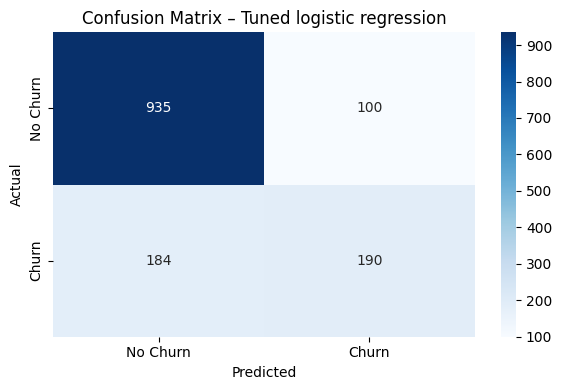

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix – Tuned logistic regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('churn_confusion_matrix.png', dpi=150)
plt.show()

In [47]:
# saving THE COMPLETE MACHINE LEARNING PIPELINE

# The complete pipeline includes both preprocessing and the trained model.
# Saving the full pipeline makes it reusable for future predictions.

joblib.dump(
    best_model.best_estimator_,
    "/content/drive/MyDrive/DHC/task2/customer_churn_pipeline.pkl"
)

print("Pipeline saved successfully to Google Drive.")

Pipeline saved successfully to Google Drive.


In [48]:
# STEP 20: LOAD THE SAVED PIPELINE
# ==========================================================

# The saved pipeline can be loaded later without retraining the model.

loaded_pipeline = joblib.load("customer_churn_pipeline.pkl")

print("Pipeline loaded successfully.")

Pipeline loaded successfully.
